In [1]:
def equal_width_binning(data, num_bins):
    min_val = min(data)
    max_val = max(data)
    bin_width = (max_val - min_val) / num_bins

    bins = []
    for i in range(num_bins):
        bins.append((min_val + i * bin_width, min_val + (i + 1) * bin_width))

    binned_data = []
    for val in data:
        for i, (low, high) in enumerate(bins):
            if (val >= low and val < high) or (i == num_bins-1 and val == high):
                binned_data.append(i)
                break
    return binned_data
data = [3, 7, 8, 5, 12, 14, 21, 13, 18]
print(equal_width_binning(data, 3))

[0, 0, 0, 0, 1, 1, 2, 1, 2]


In [2]:
def min_max_normalize(data):
    min_val = min(data)
    max_val = max(data)
    return [(x - min_val) / (max_val - min_val) for x in data]

data = [3, 7, 8, 5, 12]
print(min_max_normalize(data))


[0.0, 0.4444444444444444, 0.5555555555555556, 0.2222222222222222, 1.0]


In [4]:
def z_score_normalize(data):
    mean = sum(data) / len(data)
    variance = sum((x - mean) ** 2 for x in data) / len(data)
    stddev = variance ** 0.5
    return [(x - mean) / stddev for x in data]

data = [3, 7, 8, 5, 12]
print(z_score_normalize(data))


[-1.3187609467915742, 0.0, 0.32969023669789355, -0.6593804733957871, 1.6484511834894677]


In [5]:
import math
def t_test(sample, mu_0):
    n = len(sample)
    mean = sum(sample) / n
    variance = sum((x - mean) ** 2 for x in sample) / (n - 1)
    std_err = math.sqrt(variance) / math.sqrt(n)
    t_stat = (mean - mu_0) / std_err
    return t_stat
sample = [2.3, 2.5, 2.1, 2.6, 2.4]
mu_0 = 2.0
print("t-statistic:", t_test(sample, mu_0))

t-statistic: 4.417410272265132


In [6]:
def chi_square_test(observed, expected):
    chi_square_stat = sum((o - e) ** 2 / e for o, e in zip(observed, expected))
    return chi_square_stat
observed = [50, 30, 20]
expected = [40, 40, 20]
print("Chi-Square Statistic:", chi_square_test(observed, expected))


Chi-Square Statistic: 5.0


In [7]:
def confusion_matrix(actual, predicted):
    TP = FP = TN = FN = 0
    for a, p in zip(actual, predicted):
        if a == 1 and p == 1:
            TP += 1
        elif a == 0 and p == 1:
            FP += 1
        elif a == 0 and p == 0:
            TN += 1
        elif a == 1 and p == 0:
            FN += 1
    return {'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN}

actual =    [1,0,1,1,0,0,1,0,0,1]
predicted = [1,0,0,1,0,1,1,0,0,0]
print(confusion_matrix(actual, predicted))

{'TP': 3, 'FP': 1, 'TN': 4, 'FN': 2}


Explained variance ratio: [0.72962445 0.22850762]
PCA components:
 [[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]]


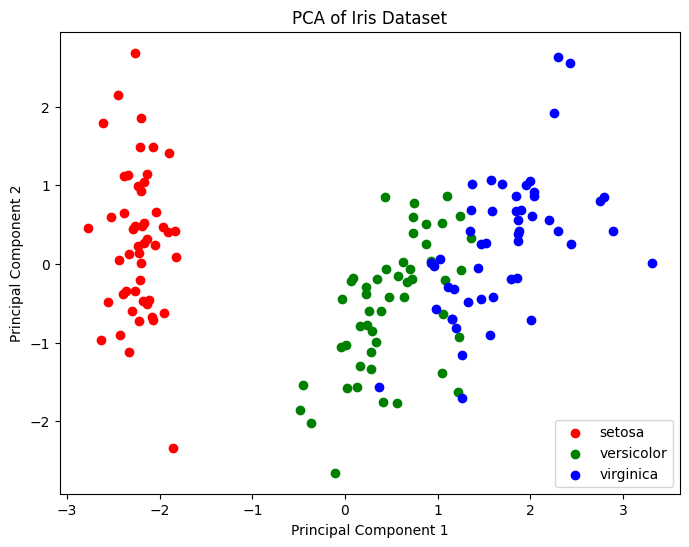

In [15]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("PCA components:\n",X_pca[:5])
import matplotlib.pyplot as plt

colors = ['r', 'g', 'b']
target_names = iris.target_names

plt.figure(figsize=(8,6))
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, label=target_name)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.show()

In [14]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained Variance Ratio:",pca.explained_variance_ratio_)
print("PCA components:\n",X_pca[:5])

Explained Variance Ratio: [0.92461872 0.05306648]
PCA components:
 [[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]


In [11]:
sample_data = """Sky,AirTemp,Humidity,Wind,Water,Forecast,EnjoySport
Sunny,Warm,Normal,Strong,Warm,Same,Yes
Sunny,Warm,High,Strong,Warm,Same,Yes
Rain,Cold,High,Strong,Warm,Change,No
Sunny,Warm,High,Strong,Cool,Change,Yes
"""

with open('training_data.csv', 'w') as f:
    f.write(sample_data)

print("Sample training_data.csv created!")

import csv

def load_data(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        data = [row for row in reader]
    return header, data

def find_s_algorithm(data):
    num_attributes = len(data[0]) - 1
    hypothesis = ['∅'] * num_attributes

    for row in data:
        attributes = row[:-1]
        label = row[-1].strip()
        if label == 'Yes':
            if hypothesis == ['∅'] * num_attributes:
                hypothesis = attributes[:]
            else:
                for i in range(num_attributes):
                    if hypothesis[i] != attributes[i]:
                        hypothesis[i] = '?'
    return hypothesis

if __name__ == "__main__":
    header, data = load_data('training_data.csv')
    hypothesis = find_s_algorithm(data)
    print("Most specific hypothesis (FIND-S):")
    print(hypothesis)

Sample training_data.csv created!
Most specific hypothesis (FIND-S):
['Sunny', 'Warm', '?', 'Strong', '?', '?']
